# Workshop 3 — Notebook 2: Gold Layer Preview

**Proyecto:** Real Madrid Pulse · Public Opinion & Sentiment Analysis
**Fuentes:** Reddit API (`r/realmadrid`) + Web scraping (`football-espana.net`)
**Equipo:** Ortiz · Cruz · Bautista — Universidad Distrital Francisco José de Caldas

---

Este notebook **lee exclusivamente los Parquet de la capa Gold** (`datalake_gold/`)
producidos por `gold_processing_dag.py` y previsualiza, de forma organizada:

1. Inventario de archivos Gold
2. Dataset Gold base (enriquecido con NLP + VADER)
3. **Governance KPIs** — calidad, volumen, completitud, duplicados, outliers, idioma
4. **Storytelling aggregations** — sentimiento, tendencias, keywords, bigramas, fuentes, aspectos
5. Metadata del run y mapeo agregación → user story → dashboard

> El Gold DAG debe haberse ejecutado al menos una vez para que existan los Parquet.


## 1. Setup

Imports, configuración de rutas y estilo visual consistente con el dashboard.

In [1]:
import os
import glob
import json
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)
pd.set_option("display.max_colwidth", 80)

# Estilo limpio para todas las gráficas
plt.rcParams.update({
    "figure.facecolor":  "white",
    "axes.facecolor":    "white",
    "axes.edgecolor":    "#ddd4c6",
    "axes.grid":         True,
    "grid.color":        "#eee8dc",
    "grid.linewidth":    0.8,
    "axes.titlesize":    12,
    "axes.titleweight":  "bold",
    "font.size":         10,
    "axes.spines.top":   False,
    "axes.spines.right": False,
})

# Paleta coherente con el dashboard de storytelling
C = {
    "positive": "#2f7d52", "neutral": "#9a9081", "negative": "#a8322d",
    "reddit":   "#c85a1f", "scraping": "#22405e", "accent": "#b08a2e",
}
SENT_C = {"positive": C["positive"], "neutral": C["neutral"], "negative": C["negative"]}

print("Setup OK ·", datetime.now().strftime("%Y-%m-%d %H:%M"))

Setup OK · 2026-05-29 19:21


## 2. Configuración de ruta Gold y helpers

`load_latest()` carga el Parquet **más reciente** que coincide con un patrón.
Es tolerante a fallos: si el archivo no existe devuelve un DataFrame vacío y
avisa, para que el notebook no se rompa si alguna agregación aún no se generó.

In [2]:
# Detecta automáticamente la carpeta Gold en los lugares más comunes
CANDIDATE_PATHS = [
    "/opt/airflow/datalake_gold",
    "../datalake_gold",
    "datalake_gold",
    "./datalake_gold",
]
GOLD_PATH = next((p for p in CANDIDATE_PATHS if os.path.isdir(p)), CANDIDATE_PATHS[0])
print(f"📂 GOLD_PATH = {GOLD_PATH}  (existe: {os.path.isdir(GOLD_PATH)})")


def load_latest(pattern, label=None):
    """Carga el Parquet más reciente que coincide con `pattern`."""
    files = glob.glob(os.path.join(GOLD_PATH, pattern))
    if not files:
        print(f"⚠️  Sin archivos para «{pattern}» — ¿ejecutaste el Gold DAG?")
        return pd.DataFrame()
    latest = max(files, key=os.path.getmtime)
    df = pd.read_parquet(latest)
    if label:
        print(f"✅ {label}: {os.path.basename(latest)}  →  {df.shape[0]} filas × {df.shape[1]} cols")
    return df


def show(df, n=5):
    """Muestra las primeras filas si hay datos."""
    return df.head(n) if not df.empty else "— sin datos —"

📂 GOLD_PATH = ../datalake_gold  (existe: True)


## 3. Inventario de archivos Gold

Todos los Parquet presentes en `datalake_gold/`, agrupados por tipo, con tamaño y fecha.

In [3]:
rows = []
for f in sorted(glob.glob(os.path.join(GOLD_PATH, "*.parquet"))):
    name = os.path.basename(f)
    family = name.rsplit("_", 2)[0] if "_" in name else name  # quita el timestamp
    rows.append({
        "archivo":   name,
        "familia":   family,
        "tamaño_kb": round(os.path.getsize(f) / 1024, 1),
        "modificado": datetime.fromtimestamp(os.path.getmtime(f)).strftime("%Y-%m-%d %H:%M"),
    })

inv = pd.DataFrame(rows)
if inv.empty:
    print("No hay archivos Gold todavía. Ejecuta el Gold DAG primero.")
else:
    print(f"Total de archivos Gold: {len(inv)} · Familias únicas: {inv['familia'].nunique()}\n")
    display(inv.sort_values(["familia", "modificado"]).reset_index(drop=True))

Total de archivos Gold: 72 · Familias únicas: 14



,archivo,familia,tamaño_kb,modificado
0,aspect_cowords_20260529_230238.parquet,aspect_cowords,5.2,2026-05-29 18:02
1,aspect_cowords_20260529_230932.parquet,aspect_cowords,5.3,2026-05-29 18:09
2,aspect_cowords_20260529_234629.parquet,aspect_cowords,5.8,2026-05-29 18:46
3,aspect_cowords_20260530_001523.parquet,aspect_cowords,5.8,2026-05-29 19:15
4,aspect_sentiment_20260529_214358.parquet,aspect_sentiment,7.1,2026-05-29 16:43
...,...,...,...,...
67,volume_trend_20260529_215406.parquet,volume_trend,2.5,2026-05-29 16:54
68,volume_trend_20260529_230238.parquet,volume_trend,2.5,2026-05-29 18:02
69,volume_trend_20260529_230932.parquet,volume_trend,2.5,2026-05-29 18:09
70,volume_trend_20260529_234629.parquet,volume_trend,2.5,2026-05-29 18:46


## 4. Gold base — dataset enriquecido

`gold_realmadrid_*.parquet` es el dataset unificado (Reddit + scraping) tras la
deduplicación global, el pipeline NLP (spaCy → `text_processed`) y VADER
(`vader_compound`, `sentiment_label`).

In [4]:
df_gold = load_latest("gold_realmadrid_*.parquet", "GOLD BASE")

if not df_gold.empty:
    if "published_at" in df_gold.columns:
        df_gold["published_at"] = pd.to_datetime(df_gold["published_at"], errors="coerce")
    print("\nColumnas y tipos:")
    display(df_gold.dtypes.to_frame("dtype"))

✅ GOLD BASE: gold_realmadrid_20260530_001519.parquet  →  280 filas × 22 cols

Columnas y tipos:


,dtype
url,str
title,str
author,str
published_at,datetime64[us]
body_text,str
body_text_clean,str
title_clean,str
body_text_missing,bool
source,str
bronze_source,str


In [5]:
# Conteo por fuente y distribución de sentimiento
if not df_gold.empty:
    print("Registros por fuente:")
    display(df_gold["source"].value_counts().to_frame("n"))
    if "sentiment_label" in df_gold.columns:
        print("\nDistribución de sentimiento:")
        display(df_gold["sentiment_label"].value_counts().to_frame("n"))

Registros por fuente:


,n
source,
scraping,200
reddit,80



Distribución de sentimiento:


,n
sentiment_label,
positive,158
negative,89
neutral,33


In [6]:
# Resumen de nulos por columna (vista rápida de completitud)
if not df_gold.empty:
    nulls = (df_gold.isnull().mean() * 100).round(2).sort_values(ascending=False)
    display(nulls.to_frame("% nulos"))

,% nulos
subreddit,71.43
num_comments,71.43
score,71.43
reading_time_min,28.57
url,0.00
title,0.00
body_text_clean,0.00
body_text,0.00
published_at,0.00
author,0.00


In [7]:
# Muestra de un registro enriquecido (texto original → procesado → VADER)
if not df_gold.empty:
    r = df_gold.iloc[0]
    cols = ["source", "title", "vader_compound", "sentiment_label", "token_count"]
    for c in cols:
        if c in df_gold.columns:
            print(f"{c:>16}: {r[c]}")
    print("\n--- body_text (original, primeros 300) ---")
    print(str(r.get("body_text", ""))[:300])
    print("\n--- text_processed (NLP, primeros 300) ---")
    print(str(r.get("text_processed", ""))[:300])

          source: scraping
           title: El Clasico return in doubt for Kylian Mbappe
  vader_compound: -0.9657
 sentiment_label: negative
     token_count: 110

--- body_text (original, primeros 300) ---
Real Madrid kept alive their slim La Liga title hopes with a 2-0 victory at Espanyol on Sunday, but they will be dashed next weekend if they fail to defeat Barcelona in El Clasico. Alvaro Arbeloa’s side are 11 points behind their arch rivals with four matches remaining, and while there is little cha

--- text_processed (NLP, primeros 300) ---
alive slim title hope victory espanyol sunday dash weekend fail defeat barcelona clasico alvaro arbeloas point arch rival remain little chance overturn deficit desperate hand trophy record clasicos start dismal defeat attempt fact eder militao arda guler involve injury mean task hard hope kylian mba


## 5. Governance KPIs

`governance_*.parquet` es un resumen de **una sola fila** con todos los KPIs de
calidad de datos. A continuación se desglosan por categoría, con sus
visualizaciones. Cada KPI está fundamentado en una observación real de la capa Silver.

In [8]:
df_gov = load_latest("governance_*.parquet", "GOVERNANCE")
gov = df_gov.iloc[0].to_dict() if not df_gov.empty else {}

def kpi(*keys):
    """Devuelve un sub-dict con las claves presentes."""
    return {k: gov[k] for k in keys if k in gov}

✅ GOVERNANCE: governance_20260530_001519.parquet  →  1 filas × 63 cols


### 5.1 Volumen y cobertura temporal

,valor
total_records,280
records_reddit,80
records_scraping,200
first_record_date,2026-05-04
last_record_date,2026-05-29
span_days,25
weeks_covered,4
days_covered,26
avg_records_per_week,70.0
avg_records_per_day,10.77


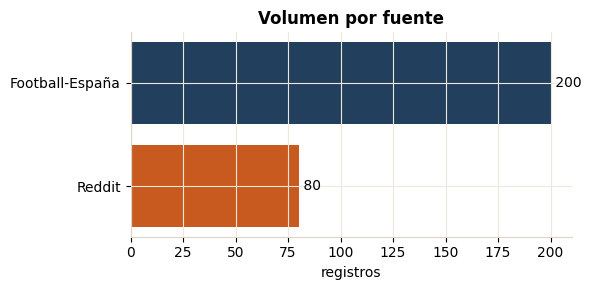

In [9]:
vol = kpi("total_records", "records_reddit", "records_scraping",
          "first_record_date", "last_record_date", "span_days",
          "weeks_covered", "days_covered", "avg_records_per_week", "avg_records_per_day")
display(pd.Series(vol, name="valor").to_frame())

if {"records_reddit", "records_scraping"} <= gov.keys():
    fig, ax = plt.subplots(figsize=(6, 3))
    ax.barh(["Reddit", "Football-España"],
            [gov["records_reddit"], gov["records_scraping"]],
            color=[C["reddit"], C["scraping"]])
    ax.set_title("Volumen por fuente"); ax.set_xlabel("registros")
    for i, v in enumerate([gov["records_reddit"], gov["records_scraping"]]):
        ax.text(v, i, f" {v}", va="center")
    plt.tight_layout(); plt.show()

### 5.2 Completitud — null rate por campo + schema compliance

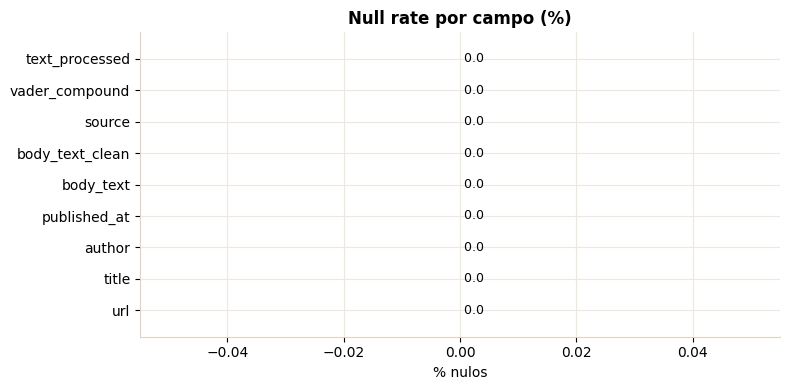

,valor
schema_compliance_rate,100.00
body_text_missing_rate,13.93


In [10]:
null_items = {k.replace("null_rate_", ""): v for k, v in gov.items() if k.startswith("null_rate_")}
if null_items:
    s = pd.Series(null_items).sort_values()
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.barh(s.index, s.values, color=C["scraping"])
    ax.set_title("Null rate por campo (%)"); ax.set_xlabel("% nulos")
    for i, v in enumerate(s.values):
        ax.text(v, i, f" {v}", va="center", fontsize=9)
    plt.tight_layout(); plt.show()

display(pd.Series(kpi("schema_compliance_rate", "body_text_missing_rate"), name="valor").to_frame())

### 5.3 Duplicados (consolidación Gold)

,valor
records_before_dedup,600.00
records_after_dedup,280.00
duplicates_removed,320.00
duplicate_rate,53.33


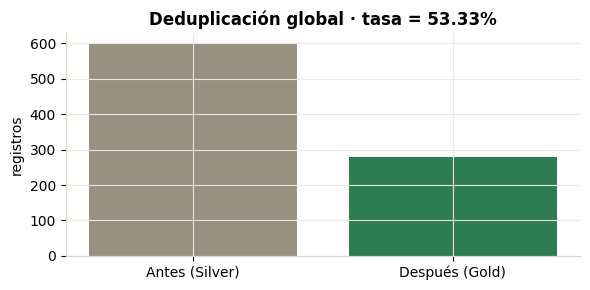

In [11]:
dup = kpi("records_before_dedup", "records_after_dedup", "duplicates_removed", "duplicate_rate")
if dup:
    display(pd.Series(dup, name="valor").to_frame())
    if {"records_before_dedup", "records_after_dedup"} <= dup.keys():
        fig, ax = plt.subplots(figsize=(6, 3))
        ax.bar(["Antes (Silver)", "Después (Gold)"],
               [dup["records_before_dedup"], dup["records_after_dedup"]],
               color=[C["neutral"], C["positive"]])
        ax.set_title(f"Deduplicación global · tasa = {dup.get('duplicate_rate', 0)}%")
        ax.set_ylabel("registros")
        plt.tight_layout(); plt.show()
else:
    print("Sin métricas de duplicados (revisa que existan Parquet en datalake_silver).")

### 5.4 Outliers por campo numérico

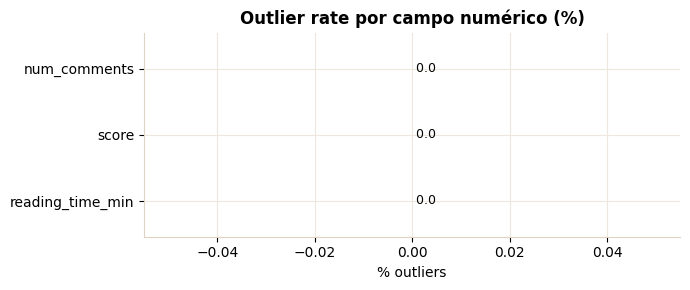

,límite
outlier_iqr_lower_reading_time_min,2.00
outlier_iqr_upper_reading_time_min,2.00
outlier_iqr_lower_score,-26.00
outlier_iqr_upper_score,46.00
outlier_iqr_lower_num_comments,-21.75
outlier_iqr_upper_num_comments,36.25


In [12]:
out_rate = {k.replace("outlier_rate_", ""): v for k, v in gov.items() if k.startswith("outlier_rate_")}
if out_rate:
    s = pd.Series(out_rate).sort_values()
    fig, ax = plt.subplots(figsize=(7, 3))
    ax.barh(s.index, s.values, color=C["accent"])
    ax.set_title("Outlier rate por campo numérico (%)"); ax.set_xlabel("% outliers")
    for i, v in enumerate(s.values):
        ax.text(v, i, f" {v}", va="center", fontsize=9)
    plt.tight_layout(); plt.show()
    # límites IQR aplicados
    iqr = {k: v for k, v in gov.items() if "outlier_iqr" in k}
    if iqr:
        display(pd.Series(iqr, name="límite").to_frame())
else:
    print("Sin KPIs de outliers.")

### 5.5 Estadísticas de longitud de texto por fuente

In [13]:
tl = {k: v for k, v in gov.items() if k.startswith("text_length")}
if tl:
    # reorganizar en tabla fuente × métrica
    recs = {}
    for k, v in tl.items():
        parts = k.replace("text_length_", "").split("_")
        metric = parts[0]
        src = parts[1] if len(parts) > 1 else "global"
        recs.setdefault(src, {})[metric] = v
    display(pd.DataFrame(recs).T)
else:
    print("Sin estadísticas de longitud de texto.")

,mean,median,min,max
global,1745.56,1727.0,0.0,29084.0
scraping,1976.46,1821.0,622.0,4484.0
reddit,1168.31,10.0,0.0,29084.0


### 5.6 Distribución de idioma (heurística)

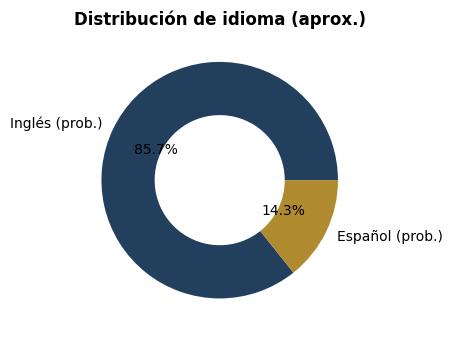

In [14]:
lang = kpi("pct_likely_english", "pct_likely_spanish")
if lang:
    fig, ax = plt.subplots(figsize=(4.5, 4.5))
    ax.pie(list(lang.values()),
           labels=["Inglés (prob.)", "Español (prob.)"],
           autopct="%1.1f%%", colors=[C["scraping"], C["accent"]],
           wedgeprops={"width": 0.45})
    ax.set_title("Distribución de idioma (aprox.)")
    plt.tight_layout(); plt.show()
else:
    print("Sin distribución de idioma.")

### 5.7 Sentimiento e índice de ánimo (resumen global)

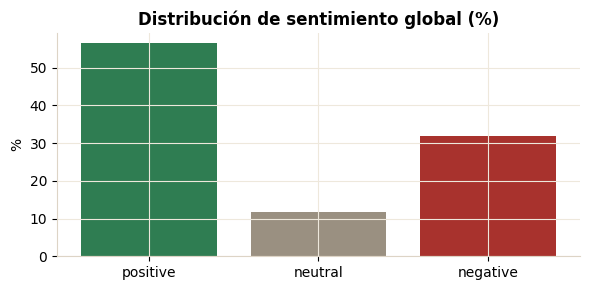

,valor
sentiment_pct_positive,56.4300
sentiment_pct_negative,31.7900
sentiment_pct_neutral,11.7900
compound_mean,0.2068
compound_std,0.6922


In [15]:
sent = {k.replace("sentiment_pct_", ""): v for k, v in gov.items() if k.startswith("sentiment_pct_")}
comp = kpi("compound_mean", "compound_std")
if sent:
    fig, ax = plt.subplots(figsize=(6, 3))
    order = [s for s in ["positive", "neutral", "negative"] if s in sent]
    ax.bar(order, [sent[s] for s in order], color=[SENT_C[s] for s in order])
    ax.set_title("Distribución de sentimiento global (%)"); ax.set_ylabel("%")
    plt.tight_layout(); plt.show()
display(pd.Series({**{f"sentiment_pct_{k}": v for k, v in sent.items()}, **comp}, name="valor").to_frame())

### 5.8 Tabla completa de KPIs

In [17]:
if gov:
    full = pd.Series(gov, name="valor").to_frame()
    full.index.name = "KPI"
    print(f"Total de KPIs en el resumen de governance: {len(gov)}")
    display(full)

Total de KPIs en el resumen de governance: 63


,valor
KPI,
pipeline_run_ts,20260530_001519
total_records,280
records_reddit,80
records_scraping,200
body_text_missing_rate,13.93
...,...
actual_runs_scraping,1
actual_runs_reddit,1
expected_runs_weekly,7


## 6. Storytelling aggregations

Cada agregación se persiste como un Parquet independiente y alimenta un componente
del dashboard de Workshop 4. Aquí se previsualizan **todas**, incluidas las nuevas
(distribución temporal de sentimiento, bigramas, palabras coocurrentes y snippets).

### 6.1 Sentiment distribution (global y por fuente)

✅ SENTIMENT DISTRIBUTION: sentiment_distribution_20260530_001523.parquet  →  6 filas × 4 cols


,source,sentiment_label,count,pct
0,reddit,negative,25,8.93
1,reddit,neutral,21,7.50
2,reddit,positive,34,12.14
3,scraping,negative,64,22.86
4,scraping,neutral,12,4.29
5,scraping,positive,124,44.29


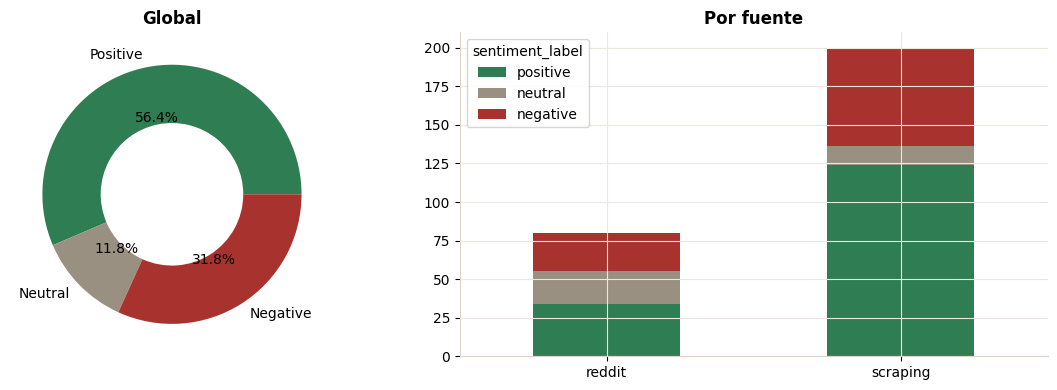

In [18]:
df_sent = load_latest("sentiment_distribution_*.parquet", "SENTIMENT DISTRIBUTION")
if not df_sent.empty:
    display(df_sent)
    g = df_sent.groupby("sentiment_label")["count"].sum()
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    order = [s for s in ["positive", "neutral", "negative"] if s in g.index]
    axes[0].pie(g[order], labels=[o.capitalize() for o in order],
                autopct="%1.1f%%", colors=[SENT_C[o] for o in order],
                wedgeprops={"width": 0.45})
    axes[0].set_title("Global")
    piv = df_sent.pivot_table(index="source", columns="sentiment_label",
                              values="count", aggfunc="sum").fillna(0)
    piv = piv[[c for c in ["positive", "neutral", "negative"] if c in piv.columns]]
    piv.plot(kind="bar", stacked=True, ax=axes[1],
             color=[SENT_C[c] for c in piv.columns])
    axes[1].set_title("Por fuente"); axes[1].set_xlabel(""); axes[1].tick_params(axis="x", rotation=0)
    plt.tight_layout(); plt.show()

### 6.2 Sentiment distribution por periodo  

✅ SENTIMENT DIST · TIME: sentiment_dist_time_20260530_001523.parquet  →  12 filas × 4 cols


,week,sentiment_label,count,pct
0,2026-05-04/2026-05-10,negative,31,51.67
1,2026-05-04/2026-05-10,neutral,2,3.33
2,2026-05-04/2026-05-10,positive,27,45.00
3,2026-05-11/2026-05-17,negative,22,37.29
4,2026-05-11/2026-05-17,neutral,8,13.56
5,2026-05-11/2026-05-17,positive,29,49.15
6,2026-05-18/2026-05-24,negative,8,17.78
7,2026-05-18/2026-05-24,neutral,2,4.44


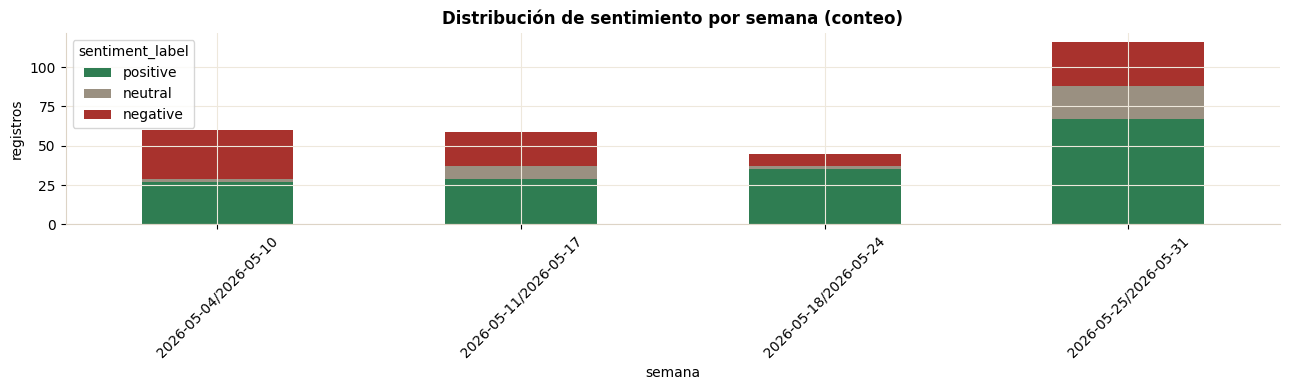

In [19]:
df_st = load_latest("sentiment_dist_time_*.parquet", "SENTIMENT DIST · TIME")
if not df_st.empty:
    display(show(df_st, 8))
    piv = df_st.pivot_table(index="week", columns="sentiment_label",
                            values="count", aggfunc="sum").fillna(0).sort_index()
    cols = [c for c in ["positive", "neutral", "negative"] if c in piv.columns]
    fig, ax = plt.subplots(figsize=(13, 4))
    piv[cols].plot(kind="bar", stacked=True, ax=ax, color=[SENT_C[c] for c in cols])
    ax.set_title("Distribución de sentimiento por semana (conteo)")
    ax.set_xlabel("semana"); ax.set_ylabel("registros")
    ax.tick_params(axis="x", rotation=45)
    plt.tight_layout(); plt.show()

### 6.3 Sentiment trend over time

✅ SENTIMENT TREND: sentiment_trend_20260530_001523.parquet  →  5 filas × 4 cols


,week,source,compound_mean,n_records
0,2026-05-04/2026-05-10,scraping,-0.0833,60
1,2026-05-11/2026-05-17,scraping,0.0878,59
2,2026-05-18/2026-05-24,scraping,0.5263,45
3,2026-05-25/2026-05-31,reddit,0.1428,80
4,2026-05-25/2026-05-31,scraping,0.6283,36


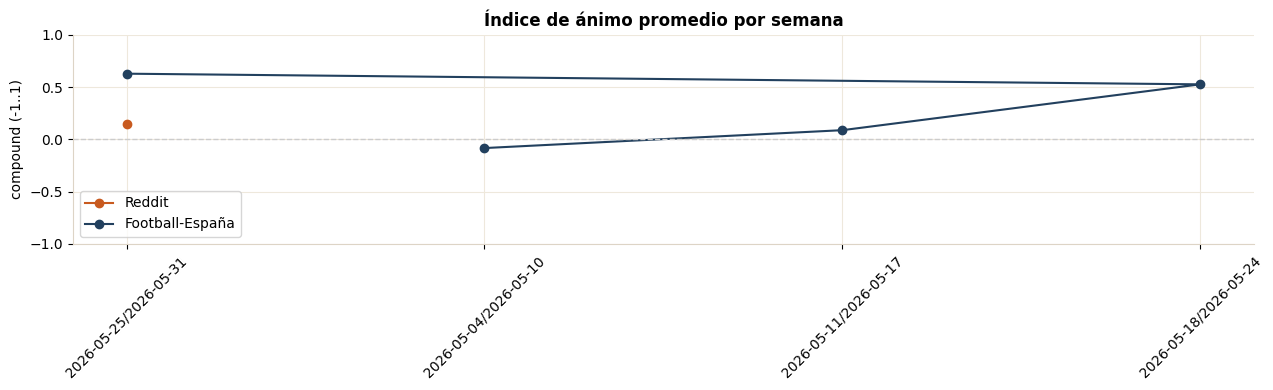

In [20]:
df_tr = load_latest("sentiment_trend_*.parquet", "SENTIMENT TREND")
if not df_tr.empty:
    display(show(df_tr, 8))
    fig, ax = plt.subplots(figsize=(13, 4))
    for src, color in [("reddit", C["reddit"]), ("scraping", C["scraping"])]:
        sub = df_tr[df_tr["source"] == src].sort_values("week")
        if not sub.empty:
            ax.plot(sub["week"], sub["compound_mean"], marker="o",
                    label="Reddit" if src == "reddit" else "Football-España", color=color)
    ax.axhline(0, color="#ccc", lw=1, ls="--")
    ax.set_title("Índice de ánimo promedio por semana"); ax.set_ylabel("compound (-1..1)")
    ax.set_ylim(-1, 1); ax.legend(); ax.tick_params(axis="x", rotation=45)
    plt.tight_layout(); plt.show()

### 6.4 Top keywords (unigramas)

✅ TOP KEYWORDS: top_keywords_20260530_001523.parquet  →  50 filas × 2 cols


,keyword,frequency
0,good,236
1,perez,226
2,win,225
3,summer,195
4,mbappe,185
5,run,182
6,arbeloa,180
7,barcelona,178
8,come,178
9,valverde,176


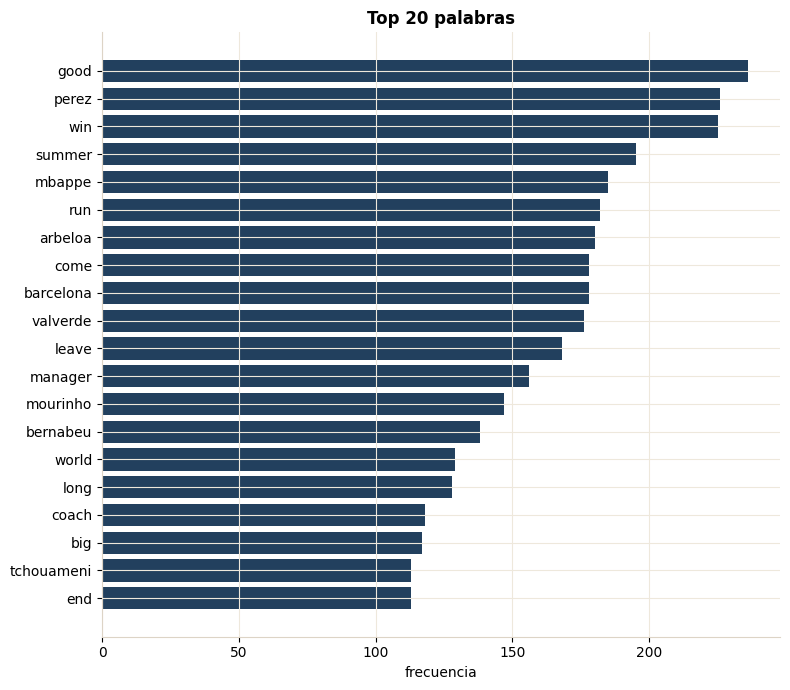

In [21]:
df_kw = load_latest("top_keywords_*.parquet", "TOP KEYWORDS")
if not df_kw.empty:
    display(show(df_kw, 10))
    top = df_kw.head(20).sort_values("frequency")
    fig, ax = plt.subplots(figsize=(8, 7))
    ax.barh(top["keyword"], top["frequency"], color=C["scraping"])
    ax.set_title("Top 20 palabras"); ax.set_xlabel("frecuencia")
    plt.tight_layout(); plt.show()

### 6.5 Top bigramas (n-grams)  *(NUEVO)*

✅ TOP BIGRAMS: top_bigrams_20260530_001523.parquet  →  30 filas × 2 cols


,bigram,frequency
0,dressing room,103
1,world cup,84
2,florentino perez,81
3,alvaro arbeloa,67
4,fede valverde,54
5,kylian mbappe,53
6,santiago bernabeu,46
7,aurelien tchouameni,46
8,jose mourinho,44
9,president florentino,43


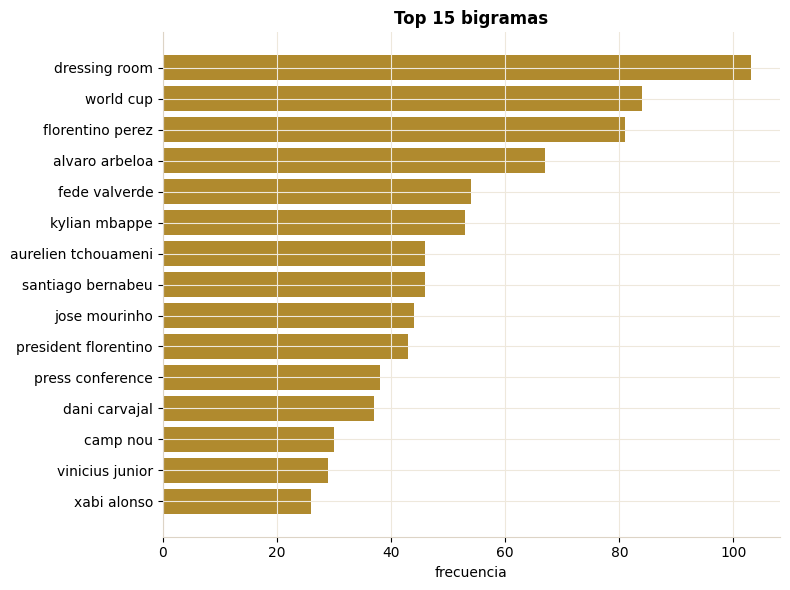

In [22]:
df_bg = load_latest("top_bigrams_*.parquet", "TOP BIGRAMS")
if not df_bg.empty:
    display(show(df_bg, 10))
    top = df_bg.head(15).sort_values("frequency")
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.barh(top["bigram"], top["frequency"], color=C["accent"])
    ax.set_title("Top 15 bigramas"); ax.set_xlabel("frecuencia")
    plt.tight_layout(); plt.show()

### 6.6 Keyword sentiment association

✅ KEYWORD SENTIMENT: keyword_sentiment_20260530_001523.parquet  →  20 filas × 4 cols


,keyword,n_mentions,compound_mean,sentiment_mode
0,good,84,0.3649,positive
1,perez,78,0.2084,positive
2,win,92,0.4305,positive
3,summer,93,0.4120,positive
4,mbappe,58,0.1590,positive
5,run,28,0.5225,positive
6,arbeloa,83,0.2373,positive
7,barcelona,88,0.1822,positive
8,come,123,0.2244,positive
9,valverde,56,-0.2208,negative


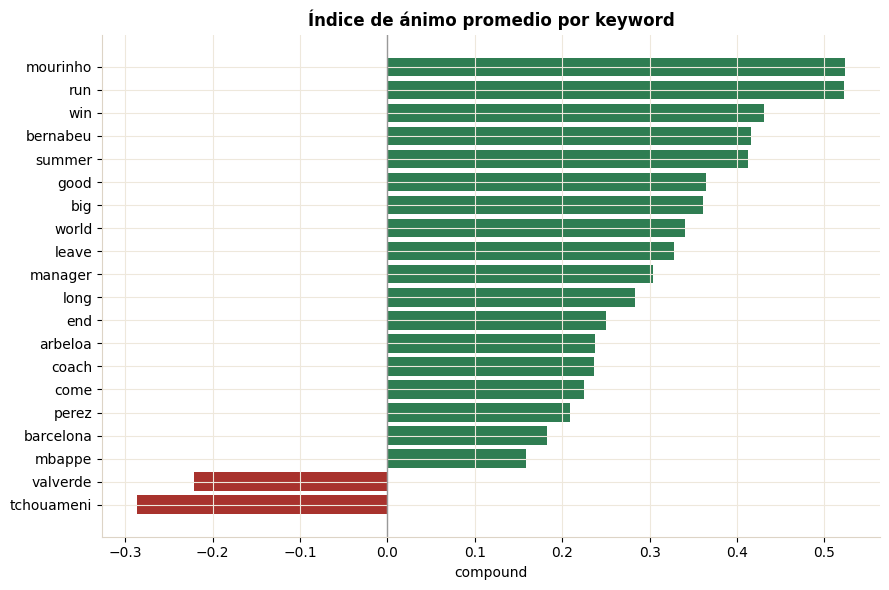

In [23]:
df_kws = load_latest("keyword_sentiment_*.parquet", "KEYWORD SENTIMENT")
if not df_kws.empty:
    display(show(df_kws, 10))
    d = df_kws.sort_values("compound_mean")
    colors = [SENT_C.get(s, C["neutral"]) for s in d.get("sentiment_mode", ["neutral"] * len(d))]
    fig, ax = plt.subplots(figsize=(9, 6))
    ax.barh(d["keyword"], d["compound_mean"], color=colors)
    ax.axvline(0, color="#999", lw=1)
    ax.set_title("Índice de ánimo promedio por keyword"); ax.set_xlabel("compound")
    plt.tight_layout(); plt.show()

### 6.7 Source comparison

✅ SOURCE COMPARISON: source_comparison_20260530_001523.parquet  →  2 filas × 8 cols


,source,n_records,compound_mean,compound_std,pct_positive,pct_neutral,pct_negative,avg_token_count
0,reddit,80,0.1428,0.5501,42.5,26.25,31.25,83.6375
1,scraping,200,0.2324,0.7411,62.0,6.00,32.00,129.2650


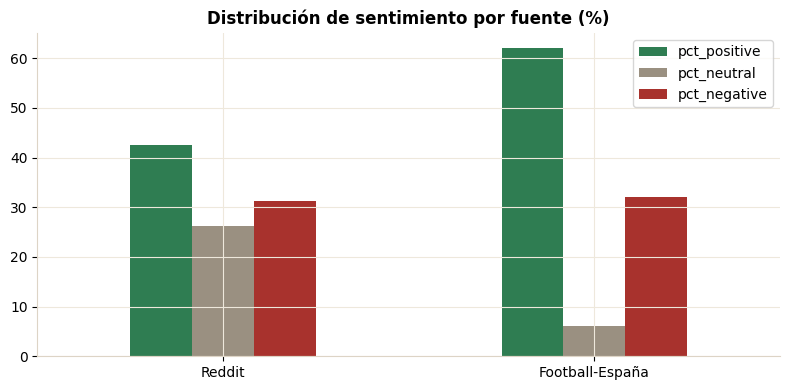

In [24]:
df_src = load_latest("source_comparison_*.parquet", "SOURCE COMPARISON")
if not df_src.empty:
    display(df_src)
    cols = [c for c in ["pct_positive", "pct_neutral", "pct_negative"] if c in df_src.columns]
    if cols:
        d = df_src.set_index("source")[cols]
        d.index = ["Reddit" if s == "reddit" else "Football-España" for s in d.index]
        fig, ax = plt.subplots(figsize=(8, 4))
        d.plot(kind="bar", ax=ax,
               color=[SENT_C[c.replace("pct_", "")] for c in cols])
        ax.set_title("Distribución de sentimiento por fuente (%)")
        ax.set_xlabel(""); ax.tick_params(axis="x", rotation=0)
        plt.tight_layout(); plt.show()

### 6.8 Volume trend

✅ VOLUME TREND: volume_trend_20260530_001523.parquet  →  5 filas × 3 cols


,week,source,n_records
0,2026-05-04/2026-05-10,scraping,60
1,2026-05-11/2026-05-17,scraping,59
2,2026-05-18/2026-05-24,scraping,45
3,2026-05-25/2026-05-31,reddit,80
4,2026-05-25/2026-05-31,scraping,36


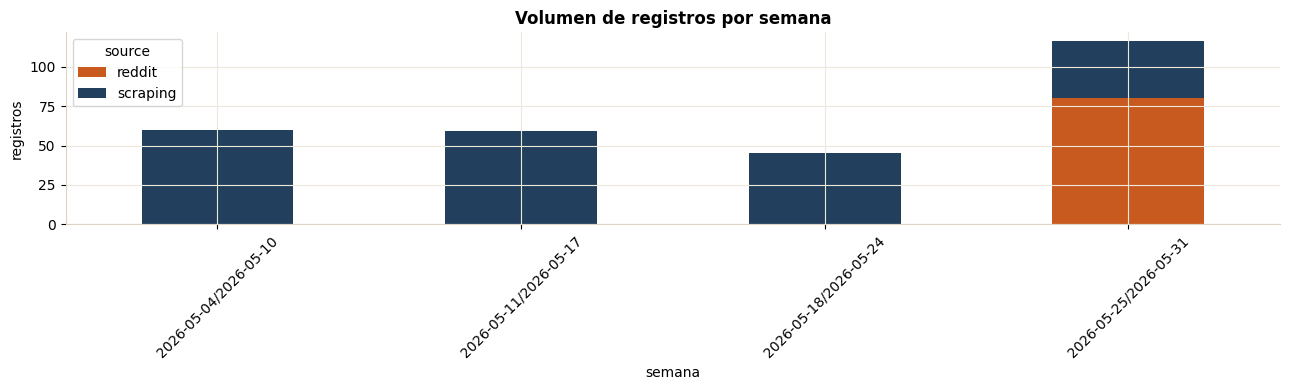

In [25]:
df_vol = load_latest("volume_trend_*.parquet", "VOLUME TREND")
if not df_vol.empty:
    display(show(df_vol, 8))
    piv = df_vol.pivot_table(index="week", columns="source",
                             values="n_records", aggfunc="sum").fillna(0).sort_index()
    fig, ax = plt.subplots(figsize=(13, 4))
    piv.plot(kind="bar", stacked=True, ax=ax,
             color=[C.get(c, C["neutral"]) for c in piv.columns])
    ax.set_title("Volumen de registros por semana"); ax.set_xlabel("semana"); ax.set_ylabel("registros")
    ax.tick_params(axis="x", rotation=45)
    plt.tight_layout(); plt.show()

### 6.9 Aspect-based sentiment (protagonistas)

✅ ASPECT SENTIMENT: aspect_sentiment_20260530_001523.parquet  →  35 filas × 9 cols


,aspect,source,n_mentions,compound_mean,compound_std,pct_positive,pct_neutral,pct_negative,sentiment_mode
30,tchouameni,all,54,-0.2855,0.7808,31.48,3.70,64.81,negative
23,valverde,all,56,-0.2208,0.7931,35.71,3.57,60.71,negative
28,clasico,all,57,-0.0528,0.7627,43.86,10.53,45.61,negative
14,injuries,all,70,0.0633,0.7770,52.86,2.86,44.29,positive
25,barcelona,all,98,0.1492,0.7828,57.14,5.10,37.76,positive
3,mbappe,all,61,0.1763,0.7795,59.02,6.56,34.43,positive
8,carvajal,all,52,0.2060,0.7645,59.62,3.85,36.54,positive
17,arbeloa,all,94,0.2098,0.7459,58.51,10.64,30.85,positive
11,transfers,all,99,0.4039,0.6570,72.73,4.04,23.23,positive
6,vinicius,all,34,0.4402,0.6471,73.53,5.88,20.59,positive


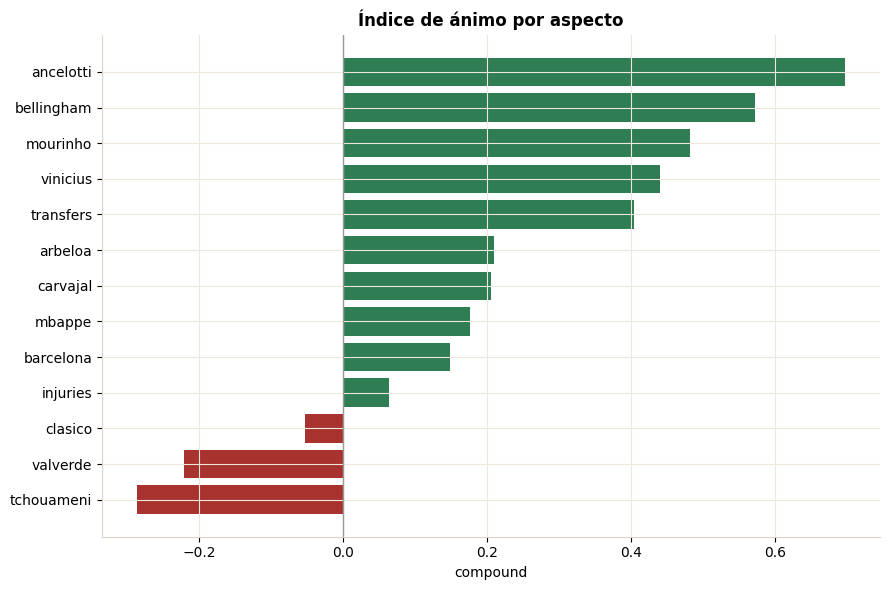

In [26]:
df_asp = load_latest("aspect_sentiment_*.parquet", "ASPECT SENTIMENT")
if not df_asp.empty:
    g = df_asp[df_asp["source"] == "all"] if "source" in df_asp.columns else df_asp
    g = g.sort_values("compound_mean")
    display(g)
    colors = [C["positive"] if v >= 0.05 else C["negative"] if v <= -0.05 else C["neutral"]
              for v in g["compound_mean"]]
    fig, ax = plt.subplots(figsize=(9, 6))
    ax.barh(g["aspect"], g["compound_mean"], color=colors)
    ax.axvline(0, color="#999", lw=1)
    ax.set_title("Índice de ánimo por aspecto"); ax.set_xlabel("compound")
    plt.tight_layout(); plt.show()

### 6.10 Palabras coocurrentes por aspecto 

✅ ASPECT COWORDS: aspect_cowords_20260530_001523.parquet  →  380 filas × 5 cols
Aspectos disponibles: ['ancelotti', 'arbeloa', 'barcelona', 'bellingham', 'carvajal', 'clasico', 'injuries', 'mbappe', 'mourinho', 'tchouameni', 'transfers', 'valverde', 'vinicius']
Mostrando: valverde


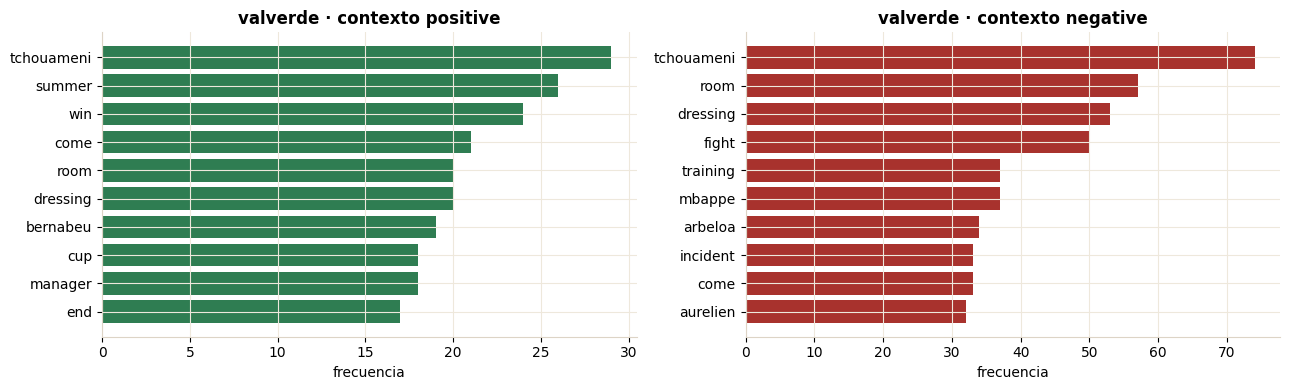

In [27]:
df_cw = load_latest("aspect_cowords_*.parquet", "ASPECT COWORDS")
if not df_cw.empty:
    aspects = sorted(df_cw["aspect"].unique())
    sample = "valverde" if "valverde" in aspects else aspects[0]
    print(f"Aspectos disponibles: {aspects}\nMostrando: {sample}")
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    for ax, pole, color in [(axes[0], "positive", C["positive"]), (axes[1], "negative", C["negative"])]:
        d = df_cw[(df_cw["aspect"] == sample) & (df_cw["sentiment"] == pole)] \
              .sort_values("frequency").tail(10)
        if not d.empty:
            ax.barh(d["word"], d["frequency"], color=color)
        ax.set_title(f"{sample} · contexto {pole}"); ax.set_xlabel("frecuencia")
    plt.tight_layout(); plt.show()

### 6.11 Snippets representativos por aspecto 

In [28]:
df_sn = load_latest("aspect_snippets_*.parquet", "ASPECT SNIPPETS")
if not df_sn.empty:
    sample = "valverde" if "valverde" in df_sn["aspect"].unique() else df_sn["aspect"].iloc[0]
    d = df_sn[df_sn["aspect"] == sample]
    for pole in ["positive", "negative"]:
        print(f"\n=== {sample.upper()} · {pole.upper()} ===")
        for _, r in d[d["sentiment_pole"] == pole].head(2).iterrows():
            print(f"  [{r['source']} · {r['vader_compound']:+.3f}] {str(r['text_snippet'])[:200]}")

✅ ASPECT SNIPPETS: aspect_snippets_20260530_001523.parquet  →  78 filas × 7 cols

=== VALVERDE · POSITIVE ===
  [scraping · +0.962] Real Madrid have had a dismal season, and it took another turn for the worse earlier this week when Aurelien Tchouameni and Fede Valverde came to blows, which resulted in the latter having to be hospi
  [scraping · +0.951] The 2025-26 season was a very tough one for Real Madrid, and it was epitomised by off-field clashes in the dressing room. Aurelien Tchouameni and Fede Valverde coming to blows earlier this month came 

=== VALVERDE · NEGATIVE ===
  [scraping · -0.987] Normally in May, there are plenty of eyes on Real Madrid as the season comes to an end, but this week the focus of the media has been trained on Valdebebas for all the wrong reasons. After several day
  [scraping · -0.978] Real Madrid midfielder Fede Valverde went to hospital after their Thursday training session, following significant fight with teammate Aurelien Tchouameni. Reports from t

## 7. Metadata del run

`storytelling_summary_*.parquet` resume el run completo del Gold DAG.

In [29]:
df_story = load_latest("storytelling_summary_*.parquet", "STORYTELLING SUMMARY")
if not df_story.empty:
    display(df_story.T.rename(columns={0: "valor"}))

✅ STORYTELLING SUMMARY: storytelling_summary_20260530_001523.parquet  →  1 filas × 9 cols


,valor
pipeline_run_ts,20260530_001523
total_records,280
sources,"['scraping', 'reddit']"
weeks_covered,4
top_keyword,good
overall_sentiment,positive
overall_compound,0.2068
aggregations_saved,"['sentiment_distribution', 'sentiment_dist_time', 'sentiment_trend', 'top_ke..."
aspects_analyzed,"['mourinho', 'mbappe', 'vinicius', 'carvajal', 'transfers', 'injuries', 'arb..."
